# Rainfall Product Performance by Climate Zone & Application
Visualising best-performing satellite/reanalysis rainfall products across West African climate zones.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Optional: nicer fonts
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130

## 1. Data

In [7]:
# ── Raw data ──────────────────────────────────────────────────────────────────
zones = ['Saharian', 'Sahelian', 'Soudanian', 'Guinean', 'Guineo-Congolean']
applications = [
    'Fire risk monitoring',
    'Wildlife & habitat',
    'Drought early warning',
    'Flood forecasting',
    'Agricultural planning',
    'Hydrological modelling',
    'Climate trend analysis',
]

# Best product and score for each (application × zone) cell
# Format: (product_name, score)
data = {
    'Fire risk monitoring':    [('GPM IMERG', 0.853), ('GPM IMERG', 0.956), ('GPM IMERG', 0.919), ('GPM IMERG', 0.895), ('GPM IMERG', 0.945)],
    'Wildlife & habitat':      [('GPM IMERG', 0.863), ('GPM IMERG', 0.967), ('GPM IMERG', 0.939), ('GPM IMERG', 0.908), ('GPM IMERG', 0.951)],
    'Drought early warning':   [('GPM IMERG', 0.865), ('GPM IMERG', 0.964), ('GPM IMERG', 0.937), ('GPM IMERG', 0.915), ('GPM IMERG', 0.954)],
    'Flood forecasting':       [('PERSIANN-CDR', 0.815), ('GPM IMERG', 0.958), ('CHIRPS', 0.924), ('GPM IMERG', 0.906), ('GPM IMERG', 0.949)],
    'Agricultural planning':   [('GPM IMERG', 0.867), ('GPM IMERG', 0.967), ('GPM IMERG', 0.940), ('GPM IMERG', 0.906), ('GPM IMERG', 0.949)],
    'Hydrological modelling':  [('PERSIANN-CDR', 0.881), ('GPM IMERG', 0.972), ('GPM IMERG', 0.947), ('GPM IMERG', 0.914), ('GPM IMERG', 0.955)],
    'Climate trend analysis':  [('GPM IMERG', 0.875), ('GPM IMERG', 0.968), ('GPM IMERG', 0.942), ('GPM IMERG', 0.909), ('GPM IMERG', 0.950)],
}

# 2nd-best product and score
data_2nd = {
    'Fire risk monitoring':    [('PERSIANN-CDR', 0.828), ('CHIRPS', 0.935), ('CHIRPS', 0.914), ('CHIRPS', 0.887), ('CHIRPS', 0.909)],
    'Wildlife & habitat':      [('PERSIANN-CDR', 0.859), ('TerraClimate', 0.949), ('CHIRPS', 0.931), ('CHIRPS', 0.891), ('CHIRPS', 0.918)],
    'Drought early warning':   [('PERSIANN-CDR', 0.843), ('TerraClimate', 0.944), ('CHIRPS', 0.933), ('CHIRPS', 0.907), ('CHIRPS', 0.925)],
    'Flood forecasting':       [('GPM IMERG', 0.815), ('TerraClimate', 0.939), ('GPM IMERG', 0.924), ('PERSIANN-CDR', 0.882), ('PERSIANN-CDR', 0.914)],
    'Agricultural planning':   [('PERSIANN-CDR', 0.858), ('TerraClimate', 0.948), ('CHIRPS', 0.929), ('CHIRPS', 0.888), ('CHIRPS', 0.916)],
    'Hydrological modelling':  [('GPM IMERG', 0.872), ('TerraClimate', 0.958), ('CHIRPS', 0.938), ('CHIRPS', 0.891), ('CHIRPS', 0.923)],
    'Climate trend analysis':  [('PERSIANN-CDR', 0.867), ('TerraClimate', 0.950), ('CHIRPS', 0.930), ('CHIRPS', 0.889), ('CHIRPS', 0.917)],
}

# Build tidy DataFrames
rows = []
for app, vals in data.items():
    for z, (prod, score) in zip(zones, vals):
        p2, s2 = data_2nd[app][zones.index(z)]
        rows.append(dict(application=app, zone=z, product=prod, score=score,
                         product_2nd=p2, score_2nd=s2))
df = pd.DataFrame(rows)

# Score matrices
score_matrix  = df.pivot(index='application', columns='zone', values='score')[zones]
score_matrix  = score_matrix.reindex(applications)

product_matrix = df.pivot(index='application', columns='zone', values='product')[zones]
product_matrix = product_matrix.reindex(applications)

print('Score matrix:')
score_matrix.round(3)

Score matrix:


zone,Saharian,Sahelian,Soudanian,Guinean,Guineo-Congolean
application,,,,,
Fire risk monitoring,0.853,0.956,0.919,0.895,0.945
Wildlife & habitat,0.863,0.967,0.939,0.908,0.951
Drought early warning,0.865,0.964,0.937,0.915,0.954
Flood forecasting,0.815,0.958,0.924,0.906,0.949
Agricultural planning,0.867,0.967,0.940,0.906,0.949
Hydrological modelling,0.881,0.972,0.947,0.914,0.955
Climate trend analysis,0.875,0.968,0.942,0.909,0.950


## 2. Colour helpers

In [8]:
PRODUCT_COLORS = {
    'GPM IMERG':   '#C0392B',   # red
    'CHIRPS':      '#2980B9',   # blue
    'PERSIANN-CDR':'#E67E22',   # orange
    'TerraClimate':'#1ABC9C',   # teal
    'ERA5-Land':   '#8E44AD',   # purple
    'MERRA-2':     '#F1C40F',   # yellow
}

ZONE_COLORS = {
    'Saharian':         '#C0392B',
    'Sahelian':         '#E67E22',
    'Soudanian':        '#27AE60',
    'Guinean':          '#27AE60',
    'Guineo-Congolean': '#1A7A4A',
}

def product_color_matrix(pmat):
    """Return an (n_app × n_zone × 4) RGBA array for imshow face-colours."""
    arr = np.zeros((*pmat.shape, 4))
    for i, app in enumerate(pmat.index):
        for j, zone in enumerate(pmat.columns):
            prod = pmat.loc[app, zone]
            rgba = mcolors.to_rgba(PRODUCT_COLORS.get(prod, '#888888'))
            arr[i, j] = rgba
    return arr

## 3. Plot A — Annotated Heatmap (scores + product winner)

AttributeError: 'function' object has no attribute 'values'

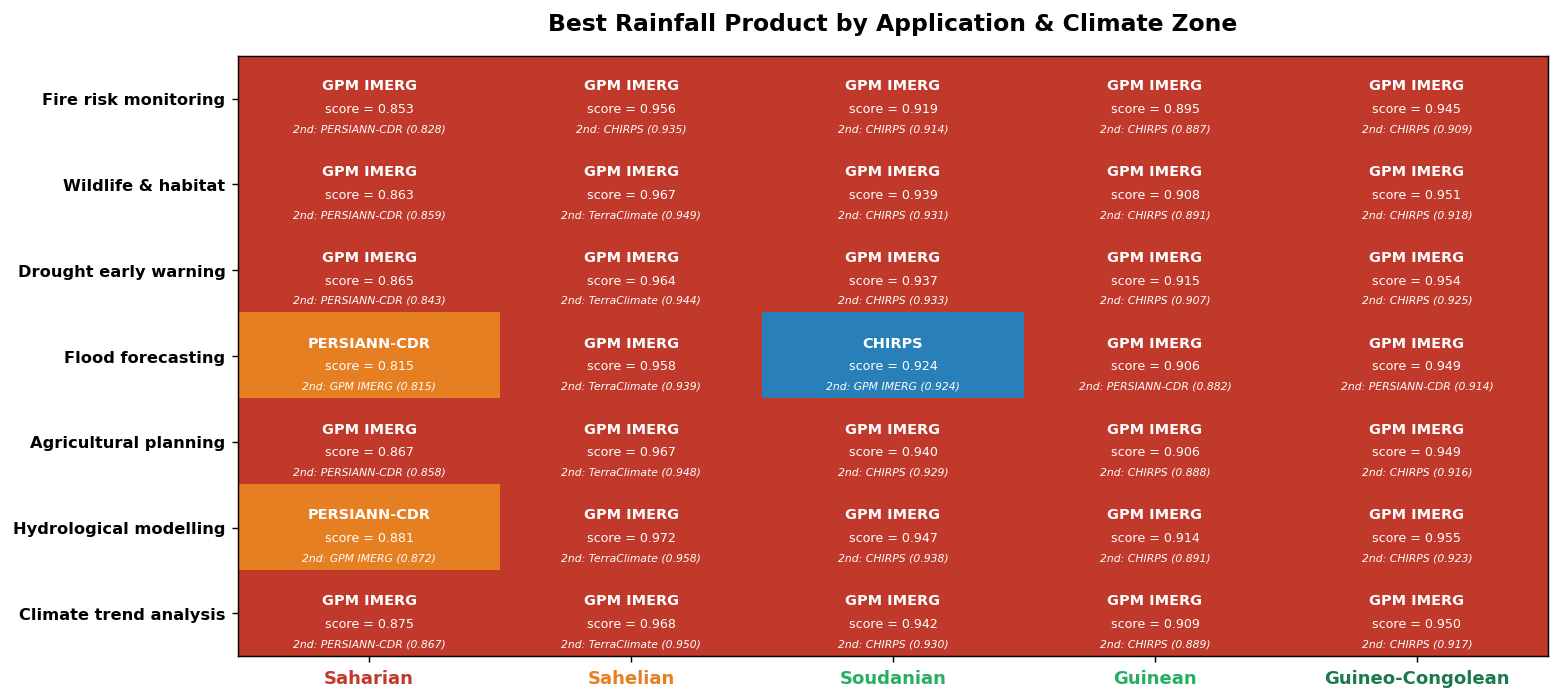

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

rgba_arr = product_color_matrix(product_matrix)
ax.imshow(rgba_arr, aspect='auto')

n_app, n_zone = score_matrix.shape

for i, app in enumerate(applications):
    for j, zone in enumerate(zones):
        prod  = product_matrix.loc[app, zone]
        score = score_matrix.loc[app, zone]
        p2    = df.loc[(df.application==app)&(df.zone==zone), 'product_2nd'].values[0]
        s2    = df.loc[(df.application==app)&(df.zone==zone), 'score_2nd'].values[0]
        ax.text(j, i-0.15, prod,  ha='center', va='center', fontsize=8,
                fontweight='bold', color='white')
        ax.text(j, i+0.12, f'score = {score:.3f}', ha='center', va='center',
                fontsize=7, color='white')
        ax.text(j, i+0.35, f'2nd: {p2} ({s2:.3f})', ha='center', va='center',
                fontsize=6, color='white', style='italic')

ax.set_xticks(range(n_zone))
ax.set_xticklabels(zones, fontsize=10, fontweight='bold')
ax.set_yticks(range(n_app))
ax.set_yticklabels(applications, fontsize=9, fontweight='bold')
ax.set_title('Best Rainfall Product by Application & Climate Zone', fontsize=13,
             fontweight='bold', pad=14)

# Colour the x-tick labels
for tick, zone in zip(ax.get_xticklabels(), zones):
    tick.set_color(ZONE_COLORS[zone])

# Legend
patches = [mpatches.Patch(color=c, label=p) for p, c in PRODUCT_COLORS.items()
           if p in df.product.values or p in df.product_2nd.values]
ax.legend(handles=patches, title='Product', bbox_to_anchor=(1.01, 1),
          loc='upper left', framealpha=0.9, fontsize=8)

plt.tight_layout()
plt.savefig('plot_A_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_A_heatmap.png')

## 4. Plot B — Score Heatmap (continuous colour scale)

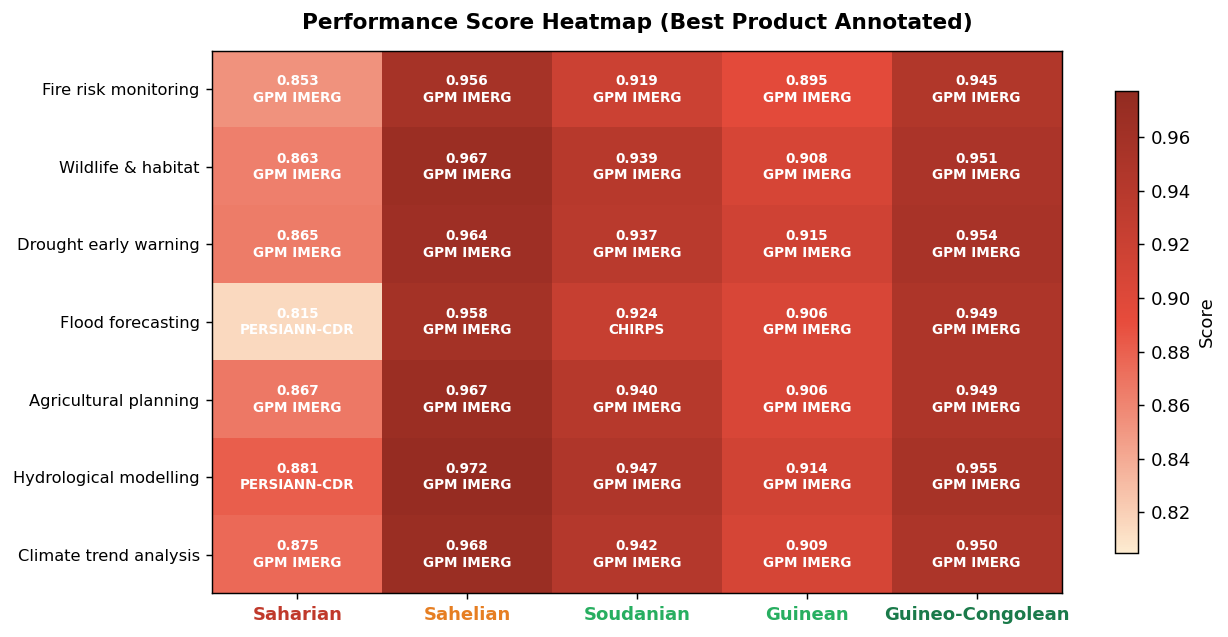

Saved → plot_B_score_heatmap.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

cmap = LinearSegmentedColormap.from_list('perf', ['#FDEBD0', '#E74C3C', '#922B21'])
im = ax.imshow(score_matrix.values, cmap=cmap,
               vmin=score_matrix.values.min()-0.01,
               vmax=score_matrix.values.max()+0.005,
               aspect='auto')

for i in range(len(applications)):
    for j in range(len(zones)):
        val  = score_matrix.values[i, j]
        prod = product_matrix.values[i, j]
        ax.text(j, i, f'{val:.3f}\n{prod}', ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold')

ax.set_xticks(range(len(zones)))
ax.set_xticklabels(zones, fontsize=10, fontweight='bold')
for tick, zone in zip(ax.get_xticklabels(), zones):
    tick.set_color(ZONE_COLORS[zone])
ax.set_yticks(range(len(applications)))
ax.set_yticklabels(applications, fontsize=9)
ax.set_title('Performance Score Heatmap (Best Product Annotated)', fontsize=12,
             fontweight='bold', pad=12)

plt.colorbar(im, ax=ax, label='Score', shrink=0.85)
plt.tight_layout()
plt.savefig('plot_B_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_B_score_heatmap.png')

## 5. Plot C — Bar Chart: Score by Zone (grouped by application)

AttributeError: 'function' object has no attribute 'values'

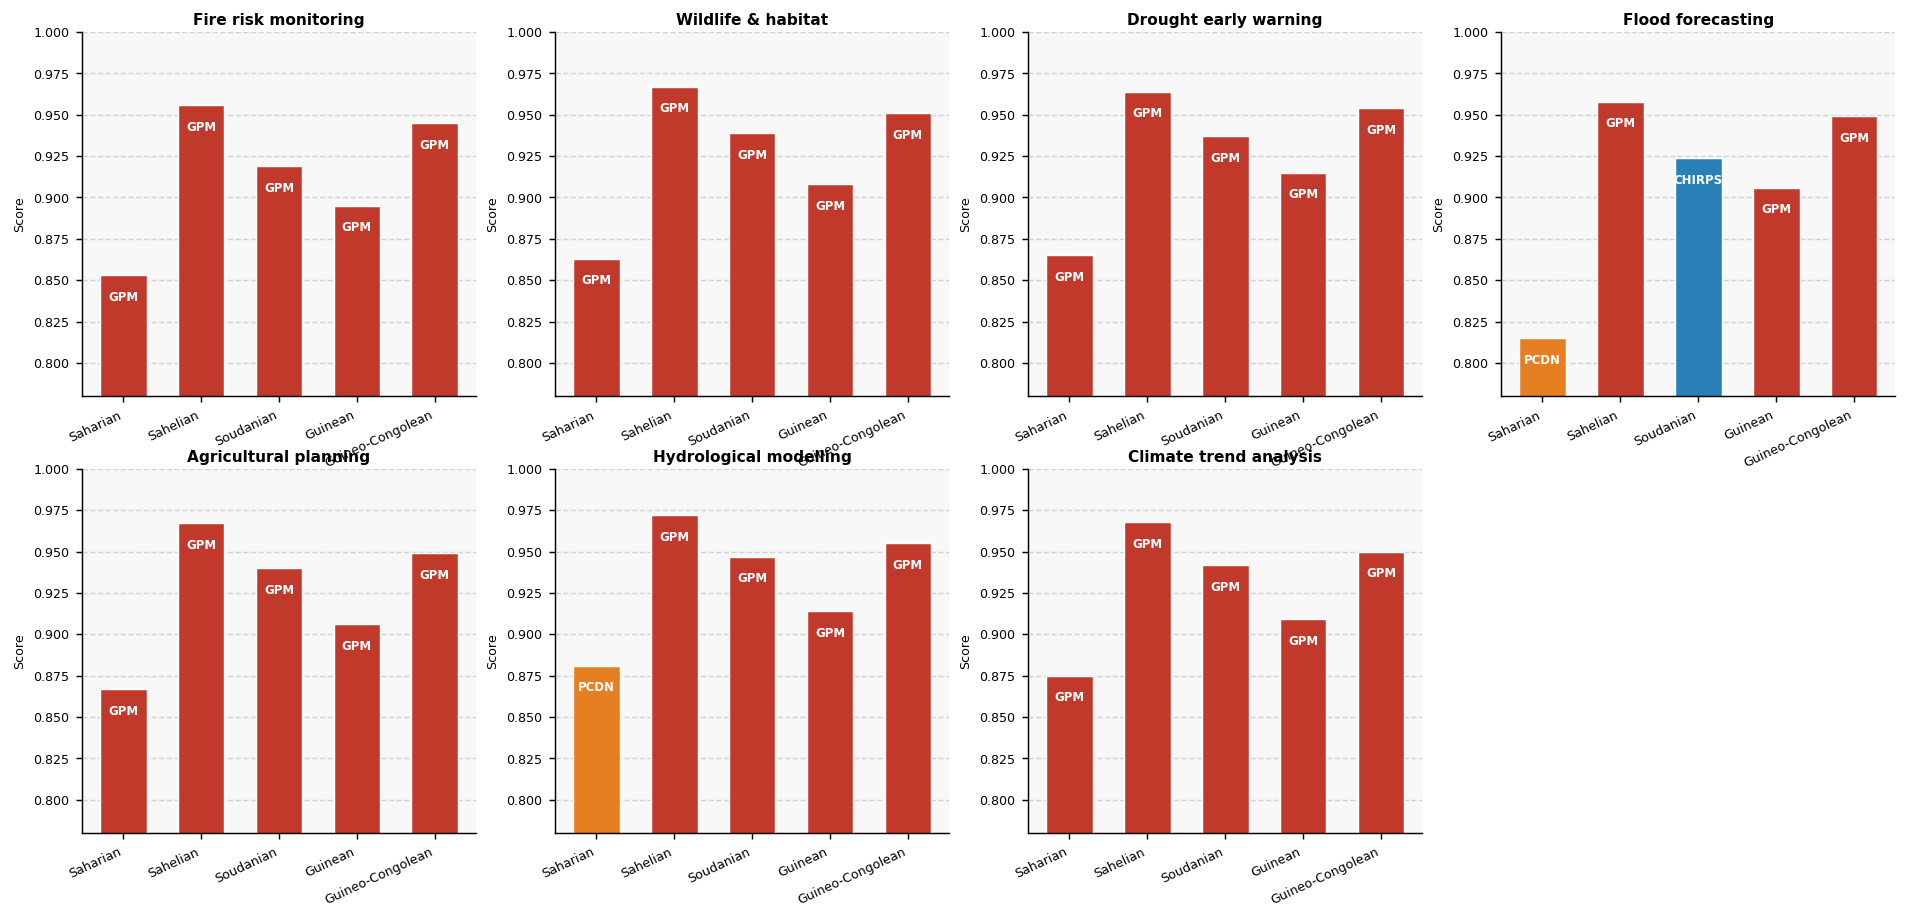

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flatten()

bar_colors = [ZONE_COLORS[z] for z in zones]

for idx, app in enumerate(applications):
    ax = axes[idx]
    scores  = [score_matrix.loc[app, z] for z in zones]
    products= [product_matrix.loc[app, z] for z in zones]
    bars = ax.bar(zones, scores, color=[PRODUCT_COLORS.get(p,'#888') for p in products],
                  edgecolor='white', linewidth=0.8, width=0.6)
    # product label inside bar
    for bar, prod, score in zip(bars, products, scores):
        short = prod.replace('GPM IMERG','GPM').replace('PERSIANN-CDR','PCDN').replace('TerraClimate','TClim')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()-0.01,
                short, ha='center', va='top', fontsize=6.5, color='white', fontweight='bold')
    ax.set_ylim(0.78, 1.00)
    ax.set_title(app, fontsize=8.5, fontweight='bold', pad=4)
    ax.set_xticklabels(zones, rotation=25, ha='right', fontsize=7)
    ax.yaxis.set_tick_params(labelsize=7)
    ax.set_ylabel('Score', fontsize=7)
    ax.spines[['top','right']].set_visible(False)
    ax.set_facecolor('#F8F8F8')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

axes[-1].set_visible(False)   # 7 apps → hide last empty panel

# Shared legend
patches = [mpatches.Patch(color=c, label=p) for p, c in PRODUCT_COLORS.items()
           if p in df.product.values]
fig.legend(handles=patches, title='Best Product', loc='lower right',
           bbox_to_anchor=(0.99, 0.03), ncol=1, fontsize=8, framealpha=0.9)

fig.suptitle('Rainfall Product Scores by Climate Zone', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_C_bar_by_app.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_C_bar_by_app.png')

## 6. Plot D — Radar / Spider Chart: Zone profiles

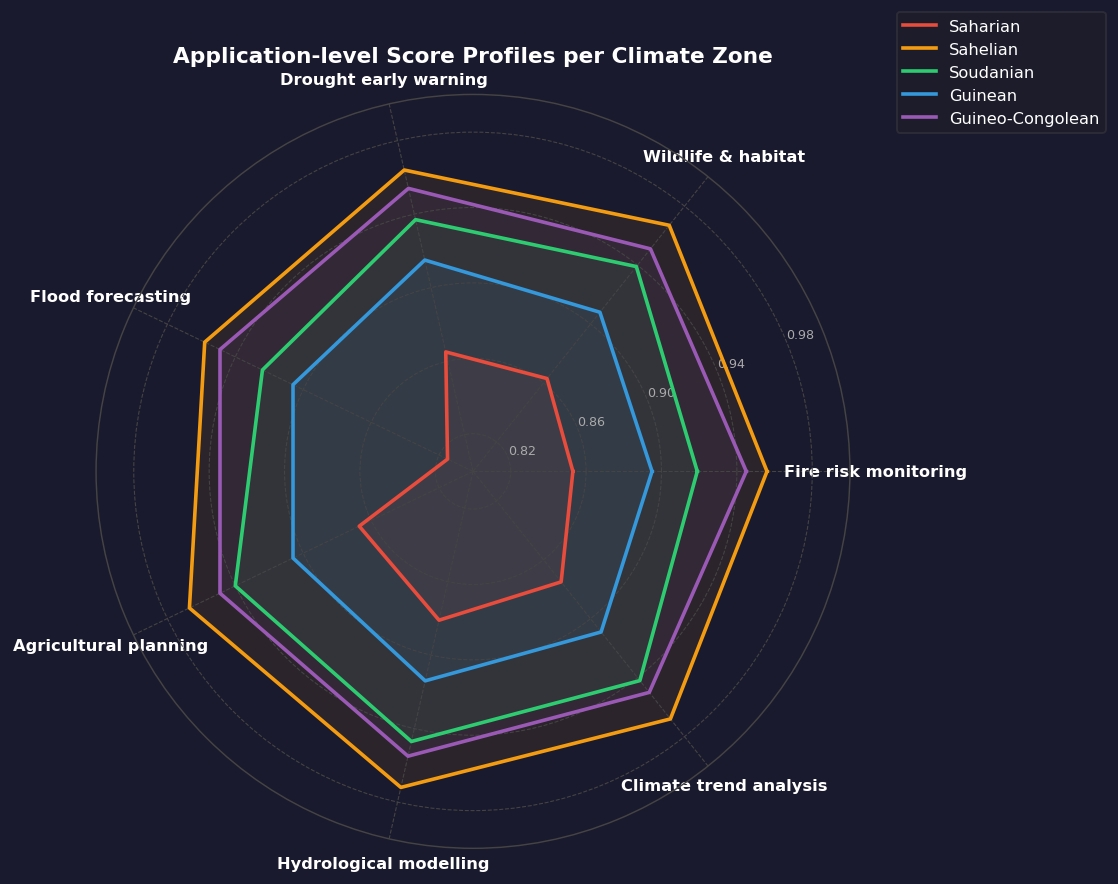

Saved → plot_D_radar.png


In [12]:
from matplotlib.patches import FancyArrowPatch

labels  = applications
N       = len(labels)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor('#1A1A2E')
fig.patch.set_facecolor('#1A1A2E')

zone_radar_colors = {
    'Saharian':         '#E74C3C',
    'Sahelian':         '#F39C12',
    'Soudanian':        '#2ECC71',
    'Guinean':          '#3498DB',
    'Guineo-Congolean': '#9B59B6',
}

for zone, color in zone_radar_colors.items():
    values  = score_matrix[zone].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=zone)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9, color='white', fontweight='bold')
ax.set_ylim(0.80, 1.00)
ax.set_yticks([0.82, 0.86, 0.90, 0.94, 0.98])
ax.set_yticklabels(['0.82','0.86','0.90','0.94','0.98'],
                   fontsize=7, color='#AAAAAA')
ax.spines['polar'].set_color('#444')
ax.grid(color='#444', linestyle='--', linewidth=0.6)
ax.set_title('Application-level Score Profiles per Climate Zone',
             fontsize=12, fontweight='bold', color='white', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12),
          fontsize=9, framealpha=0.3, labelcolor='white',
          facecolor='#222', edgecolor='#555')

plt.tight_layout()
plt.savefig('plot_D_radar.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved → plot_D_radar.png')

## 7. Plot E — Gap between 1st & 2nd place (margin of victory)

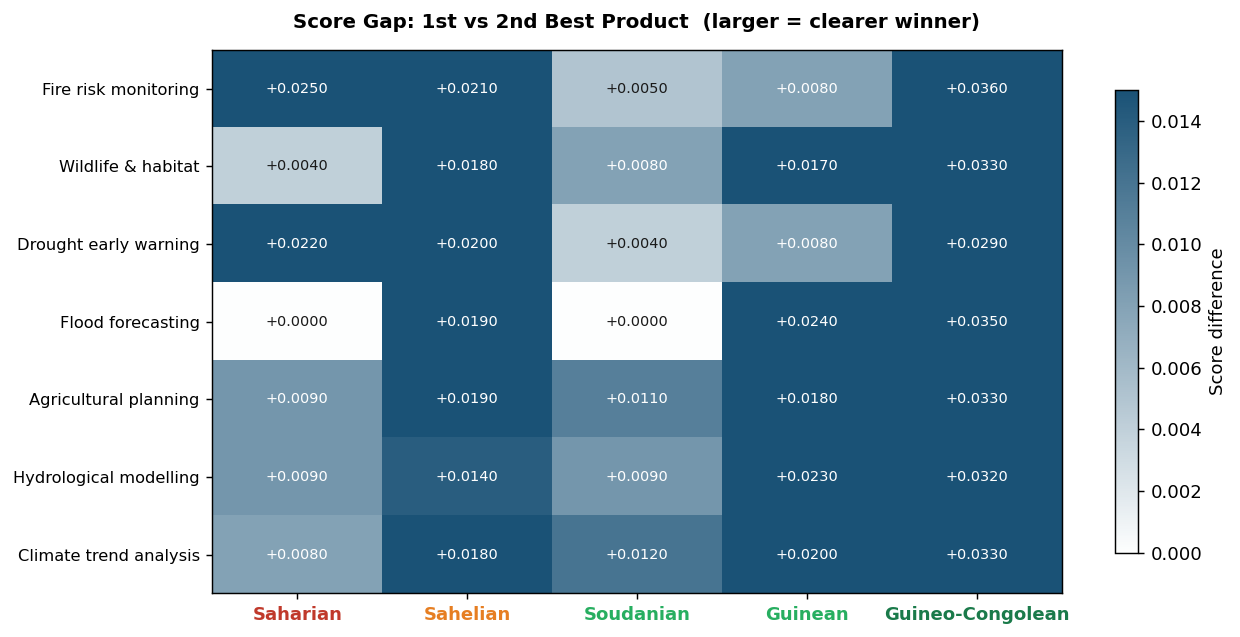

Saved → plot_E_gap.png


In [13]:
df['gap'] = (df['score'] - df['score_2nd']).round(4)
gap_matrix = df.pivot(index='application', columns='zone', values='gap')[zones]
gap_matrix = gap_matrix.reindex(applications)

fig, ax = plt.subplots(figsize=(10, 5))
cmap_gap = LinearSegmentedColormap.from_list('gap', ['#FDFEFE', '#1A5276'])
im = ax.imshow(gap_matrix.values, cmap=cmap_gap, vmin=0, vmax=0.015, aspect='auto')

for i in range(len(applications)):
    for j in range(len(zones)):
        val = gap_matrix.values[i, j]
        color = 'white' if val > 0.007 else '#1A1A1A'
        ax.text(j, i, f'+{val:.4f}', ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(zones)))
ax.set_xticklabels(zones, fontsize=10, fontweight='bold')
for tick, zone in zip(ax.get_xticklabels(), zones):
    tick.set_color(ZONE_COLORS[zone])
ax.set_yticks(range(len(applications)))
ax.set_yticklabels(applications, fontsize=9)
ax.set_title('Score Gap: 1st vs 2nd Best Product  (larger = clearer winner)',
             fontsize=11, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax, label='Score difference', shrink=0.85)
plt.tight_layout()
plt.savefig('plot_E_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_E_gap.png')

## 8. Summary stats

In [14]:
print('=== Mean score by climate zone ===')
print(df.groupby('zone')['score'].mean().reindex(zones).round(4).to_string())

print('\n=== Mean score by application ===')
print(df.groupby('application')['score'].mean().reindex(applications).round(4).to_string())

print('\n=== Best-product win count ===')
print(df['product'].value_counts().to_string())

=== Mean score by climate zone ===
zone
Saharian            0.8599
Sahelian            0.9646
Soudanian           0.9354
Guinean             0.9076
Guineo-Congolean    0.9504

=== Mean score by application ===
application
Fire risk monitoring      0.9136
Wildlife & habitat        0.9256
Drought early warning     0.9270
Flood forecasting         0.9104
Agricultural planning     0.9258
Hydrological modelling    0.9338
Climate trend analysis    0.9288

=== Best-product win count ===
product
GPM IMERG       32
PERSIANN-CDR     2
CHIRPS           1
